# Explained baseline for the *PhysioNet - Digitization of ECG Images* competition

This notebook contributes three innovations to the competition:
1. It shows how to find the markers in a scanned ECG (object detection in class `MarkerFinder`).
1. It visualizes how to extract the time series from images of types 3 and 11 with a top-down plane sweep (function `convert_scanned_color()`).
1. It shows how to extract the time series from grayscale images with a neural network (function `convert_scanned_grayscale()`).

You can run this notebook with or without GPU, depending on your patience and your GPU quota.

## Training data overview

There are 977 electrocardiograms (ids) in train, accounting for 84 GByte. Every electrocardiogram has 9 PNG files and one CSV file.

There are nine image types per ECG:
- 0001 Original color ECG image generated by ECG-image-kit.
- 0003 Image printed in color and scanned in color. → processed by `convert_scanned_color()`
- 0004 Image printed in color and scanned in black and white. → processed by `convert_scanned_grayscale()`
- 0005 Mobile photos of color printed images.
- 0006 Mobile photos of ECGs on the screen of laptop.
- 0009 Mobile photos of stained and soaked printed ECGs.
- 0010 Mobile photos of printed ECGs with extensive damage.
- 0011 Scans of printed ECG images with mold in color. → processed by `convert_scanned_color()`
- 0012 Scans of printed ECG images with mold in black and white. → processed by `convert_scanned_grayscale()`

The sampling frequencies in train are 250, 256, 500, 512, 1000, 1025 per second.

## Hall of fame / acknowledgements

This notebook was influenced by the work of
- @sasaleaf ([Edge Fix | small Improvement](https://www.kaggle.com/code/sasaleaf/edge-fix-small-improvement))
- @guntasdhanjal ([ECG Digitization - Signal Smoothing Enhancement](https://www.kaggle.com/code/guntasdhanjal/ecg-digitization-signal-smoothing-enhancement))
- @seowoohyeon ([PhysioNet_adjust](https://www.kaggle.com/code/seowoohyeon/physionet-adjust))
- @antonoof ([large EDA and statistical model]())

I thank them for publishing their ideas.

In [1]:
import pandas as pd
import numpy as np
import cv2
from glob import glob
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
from scipy.signal import medfilt

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

from tensorflow.keras.layers import Input, Dense, Activation, Reshape, GaussianNoise
from tensorflow.keras.initializers import Constant
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TerminateOnNaN

2026-03-18 13:25:26.668028: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773840326.862754      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773840326.919521      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Auxiliary functions

In [2]:
# Competition metric
# From https://www.kaggle.com/code/metric/physionet-ecg-signal-extraction-metric
from typing import Tuple

import numpy as np
import pandas as pd

import scipy.optimize
import scipy.signal


LEADS = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
MAX_TIME_SHIFT = 0.2
PERFECT_SCORE = 384


class ParticipantVisibleError(Exception):
    pass


def compute_power(label: np.ndarray, prediction: np.ndarray) -> Tuple[float, float]:
    if label.ndim != 1 or prediction.ndim != 1:
        raise ParticipantVisibleError('Inputs must be 1-dimensional arrays.')
    finite_mask = np.isfinite(prediction)
    if not np.any(finite_mask):
        raise ParticipantVisibleError("The 'prediction' array contains no finite values (all NaN or inf).")

    prediction[~np.isfinite(prediction)] = 0
    noise = label - prediction
    p_signal = np.sum(label**2)
    p_noise = np.sum(noise**2)
    return p_signal, p_noise


def compute_snr(signal: float, noise: float) -> float:
    if noise == 0:
        # Perfect reconstruction
        snr = PERFECT_SCORE
    elif signal == 0:
        snr = 0
    else:
        snr = min((signal / noise), PERFECT_SCORE)
    return snr


def align_signals(label: np.ndarray, pred: np.ndarray, max_shift: float = float('inf')) -> np.ndarray:
    if np.any(~np.isfinite(label)):
        raise ParticipantVisibleError('values in label should all be finite')
    if np.sum(np.isfinite(pred)) == 0:
        raise ParticipantVisibleError('prediction can not all be infinite')

    # Initialize the reference and digitized signals.
    label_arr = np.asarray(label, dtype=np.float64)
    pred_arr = np.asarray(pred, dtype=np.float64)

    label_mean = np.mean(label_arr)
    pred_mean = np.mean(pred_arr)

    label_arr_centered = label_arr - label_mean
    pred_arr_centered = pred_arr - pred_mean

    # Compute the correlation between the reference and digitized signals and locate the maximum correlation.
    correlation = scipy.signal.correlate(label_arr_centered, pred_arr_centered, mode='full')

    n_label = np.size(label_arr)
    n_pred = np.size(pred_arr)

    lags = scipy.signal.correlation_lags(n_label, n_pred, mode='full')
    valid_lags_mask = (lags >= -max_shift) & (lags <= max_shift)

    max_correlation = np.nanmax(correlation[valid_lags_mask])
    all_max_indices = np.flatnonzero(correlation == max_correlation)
    best_idx = min(all_max_indices, key=lambda i: abs(lags[i]))
    time_shift = lags[best_idx]
    start_padding_len = max(time_shift, 0)
    pred_slice_start = max(-time_shift, 0)
    pred_slice_end = min(n_label - time_shift, n_pred)
    end_padding_len = max(n_label - n_pred - time_shift, 0)
    aligned_pred = np.concatenate((np.full(start_padding_len, np.nan), pred_arr[pred_slice_start:pred_slice_end], np.full(end_padding_len, np.nan)))

    def objective_func(v_shift):
        return np.nansum((label_arr - (aligned_pred - v_shift)) ** 2)

    if np.any(np.isfinite(label_arr) & np.isfinite(aligned_pred)):
        results = scipy.optimize.minimize_scalar(objective_func, method='Brent')
        vertical_shift = results.x
        aligned_pred -= vertical_shift
    return aligned_pred


def _calculate_image_score(group: pd.DataFrame) -> float:
    """Helper function to calculate the total SNR score for a single image group."""

    unique_fs_values = group['fs'].unique()
    if len(unique_fs_values) != 1:
        raise ParticipantVisibleError('Sampling frequency should be consistent across each ecg')
    sampling_frequency = unique_fs_values[0]
    if sampling_frequency != int(len(group[group['lead'] == 'II']) / 10):
        raise ParticipantVisibleError('The sequence_length should be sampling frequency * 10s')
    sum_signal = 0
    sum_noise = 0
    for lead in LEADS:
        sub = group[group['lead'] == lead]
        label = sub['value_true'].values
        pred = sub['value_pred'].values

        aligned_pred = align_signals(label, pred, int(sampling_frequency * MAX_TIME_SHIFT))
        p_signal, p_noise = compute_power(label, aligned_pred)
        sum_signal += p_signal
        sum_noise += p_noise
    return compute_snr(sum_signal, sum_noise)


def score(solution: pd.DataFrame, submission: pd.DataFrame, row_id_column_name: str) -> float:
    """
    Compute the mean Signal-to-Noise Ratio (SNR) across multiple ECG leads and images for the PhysioNet 2025 competition.
    The final score is the average of the sum of SNRs over different lines, averaged over all unique images.
    Args:
        solution: DataFrame with ground truth values. Expected columns: 'id' and one for each lead.
        submission: DataFrame with predicted values. Expected columns: 'id' and one for each lead.
        row_id_column_name: The name of the unique identifier column, typically 'id'.
    Returns:
        The final competition score.

    Examples
    --------
    >>> import pandas as pd
    >>> import numpy as np
    >>> row_id_column_name = "id"
    >>> solution = pd.DataFrame({'id': ['343_0_I', '343_1_I', '343_2_I', '343_0_III', '343_1_III','343_2_III','343_0_aVR', '343_1_aVR','343_2_aVR',\
    '343_0_aVL', '343_1_aVL', '343_2_aVL', '343_0_aVF', '343_1_aVF','343_2_aVF','343_0_V1', '343_1_V1', '343_2_V1','343_0_V2', '343_1_V2','343_2_V2',\
    '343_0_V3', '343_1_V3', '343_2_V3','343_0_V4', '343_1_V4', '343_2_V4', '343_0_V5', '343_1_V5','343_2_V5','343_0_V6', '343_1_V6','343_2_V6',\
    '343_0_II', '343_1_II','343_2_II', '343_3_II', '343_4_II', '343_5_II','343_6_II', '343_7_II','343_8_II','343_9_II','343_10_II','343_11_II'],\
    'fs': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],\
    'value':[0.1,0.3,0.4,0.6,0.6,0.4,0.2,0.3,0.4,0.5,0.2,0.7,0.2,0.3,0.4,0.8,0.6,0.7, 0.2,0.3,-0.1,0.5,0.6,0.7,0.2,0.9,0.4,0.5,0.6,0.7,0.1,0.3,0.4,\
    0.6,0.6,0.4,0.2,0.3,0.4,0.5,0.2,0.7,0.2,0.3,0.4]})
    >>> submission = solution.copy()
    >>> round(score(solution, submission, row_id_column_name), 4)
    25.8433
    >>> submission.loc[0, 'value'] = 0.9 # Introduce some noise
    >>> round(score(solution, submission, row_id_column_name), 4)
    13.6291
    >>> submission.loc[4, 'value'] = 0.3 # Introduce some noise
    >>> round(score(solution, submission, row_id_column_name), 4)
    13.0576

    >>> solution = pd.DataFrame({'id': ['343_0_I', '343_1_I', '343_2_I', '343_0_III', '343_1_III','343_2_III','343_0_aVR', '343_1_aVR','343_2_aVR',\
    '343_0_aVL', '343_1_aVL', '343_2_aVL', '343_0_aVF', '343_1_aVF','343_2_aVF','343_0_V1', '343_1_V1', '343_2_V1','343_0_V2', '343_1_V2','343_2_V2',\
    '343_0_V3', '343_1_V3', '343_2_V3','343_0_V4', '343_1_V4', '343_2_V4', '343_0_V5', '343_1_V5','343_2_V5','343_0_V6', '343_1_V6','343_2_V6',\
    '343_0_II', '343_1_II','343_2_II', '343_3_II', '343_4_II', '343_5_II','343_6_II', '343_7_II','343_8_II','343_9_II','343_10_II','343_11_II'],\
    'fs': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],\
    'value':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]})
    >>> round(score(solution, submission, row_id_column_name), 4)
    -384
    >>> submission = solution.copy()
    >>> round(score(solution, submission, row_id_column_name), 4)
    25.8433

    >>> # test alignment
    >>> label = np.array([0, 1, 2, 1, 0])
    >>> pred = np.array([0, 1, 2, 1, 0])
    >>> aligned = align_signals(label, pred)
    >>> expected_array = np.array([0, 1, 2, 1, 0])
    >>> np.allclose(aligned, expected_array, equal_nan=True)
    True

    >>> # Test 2: Vertical shift (DC offset) should be removed
    >>> label = np.array([0, 1, 2, 1, 0])
    >>> pred = np.array([10, 11, 12, 11, 10])
    >>> aligned = align_signals(label, pred)
    >>> expected_array = np.array([0, 1, 2, 1, 0])
    >>> np.allclose(aligned, expected_array, equal_nan=True)
    True

    >>> # Test 3: Time shift should be corrected
    >>> label = np.array([0, 0, 1, 2, 1, 0., 0.])
    >>> pred = np.array([1, 2, 1, 0, 0, 0, 0])
    >>> aligned = align_signals(label, pred)
    >>> expected_array = np.array([np.nan, np.nan, 1, 2, 1, 0, 0])
    >>> np.allclose(aligned, expected_array, equal_nan=True)
    True
    
    >>> # Test 4: max_shift constraint prevents optimal alignment
    >>> label = np.array([0, 0, 0, 0, 1, 2, 1]) # Peak is far
    >>> pred = np.array([1, 2, 1, 0, 0, 0, 0])
    >>> aligned = align_signals(label, pred, max_shift=10)
    >>> expected_array = np.array([ np.nan, np.nan, np.nan, np.nan, 1, 2, 1])
    >>> np.allclose(aligned, expected_array, equal_nan=True)
    True

    """
    for df in [solution, submission]:
        if row_id_column_name not in df.columns:
            raise ParticipantVisibleError(f"'{row_id_column_name}' column not found in DataFrame.")
        if df['value'].isna().any():
            raise ParticipantVisibleError('NaN exists in solution/submission')
        if not np.isfinite(df['value']).all():
            raise ParticipantVisibleError('Infinity exists in solution/submission')

    submission = submission[['id', 'value']]
    merged_df = pd.merge(solution, submission, on=row_id_column_name, suffixes=('_true', '_pred'))
    merged_df['image_id'] = merged_df[row_id_column_name].str.split('_').str[0]
    merged_df['row_id'] = merged_df[row_id_column_name].str.split('_').str[1].astype('int64')
    merged_df['lead'] = merged_df[row_id_column_name].str.split('_').str[2]
    merged_df.sort_values(by=['image_id', 'row_id', 'lead'], inplace=True)
    image_scores = merged_df.groupby('image_id').apply(_calculate_image_score, include_groups=False)
    return max(float(10 * np.log10(image_scores.mean())), -PERFECT_SCORE)

In [3]:
def plot_training_history(history):
    """Plot a Keras training history."""
    if len(history['loss']) >= 2:
        _, axs = plt.subplots(1, 1, figsize=(6, 3), squeeze=False)
        axs = axs.ravel()
        axs[0].plot(np.arange(len(history['loss'])) + 1, history['loss'], ':', label='train_loss')
        axs[0].plot(np.arange(len(history['val_loss'])) + 1, history['val_loss'], label='val_loss')
        axs[0].legend()
        axs[0].set_title('Training history')
        plt.show()

## Reading the metadata and the labels

In [4]:
train = pd.read_csv('/kaggle/input/physionet-ecg-image-digitization/train.csv')
test = pd.read_csv('/kaggle/input/physionet-ecg-image-digitization/test.csv')
label_dict = {}
for idx, row in tqdm(train.iterrows(), total=len(train)):
    label_dict[idx] = pd.read_csv(f'/kaggle/input/physionet-ecg-image-digitization/train/{row.id}/{row.id}.csv')

100%|██████████| 977/977 [00:16<00:00, 58.65it/s]


## Looping through the training dataset

We define a generator function `train_images_and_labels`, which loops through a subset of the training images.

In [5]:
def train_images_and_labels(start=None, end=None, image_types=None, use_tqdm=True):
    """Generator function which yields a subset of the training images.
    
    Parameters
    start: start index of slice
    end: end index of slice
    image_types: list of image types to select
    """
    t = train.iloc[start:end]
    iterable = t.iterrows()
    if use_tqdm:
        iterable = tqdm(iterable, total=len(t))
    for idx, row in iterable:
        png_paths = sorted(glob(f'/kaggle/input/physionet-ecg-image-digitization/train/{row.id}/{row.id}-*.png'))
        labels = label_dict[idx]
        for path in png_paths:
            img_type = int(path[-8:-4])
            if image_types is None or img_type in image_types:
                ima = cv2.imread(path)

                # The following lines document the possible shapes for every image type in train
                # Test files may be different
                shape = ima.shape
                assert len(shape) == 3
                assert (img_type == 1) <= (shape == (1700, 2200, 3)) # 200 pixels per inch on Letter paper
                assert (img_type == 3) <= (shape[0] == 1652)
                assert (img_type == 4) <= (shape[0] == 1652)
                assert (img_type == 5) <= (shape in {(3024, 4032, 3), (1344, 1008, 3), (4032, 3024, 3)})
                assert (img_type == 6) <= ((shape == (4000, 3000, 3) or (shape == (3000, 4000, 3))))
                assert (img_type == 9) <= ((shape == (3024, 4032, 3) or (shape == (4032, 3024, 3))))
                assert (img_type == 10) <= ((shape == (3024, 4032, 3) or (shape == (4032, 3024, 3))))
                assert (img_type == 11) <= (shape[0] == 1652)
                assert (img_type == 12) <= (shape[0] == 1652)

                yield idx, ima, img_type, labels


## The average ECG

For regression tasks, the average of the true labels is often a good baseline. 

We compute the mean time series per lead so that we can predict this mean for those image types which our model cannot handle.

100%|██████████| 977/977 [00:02<00:00, 361.80it/s]


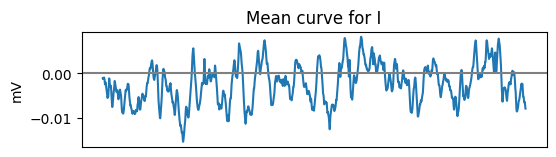

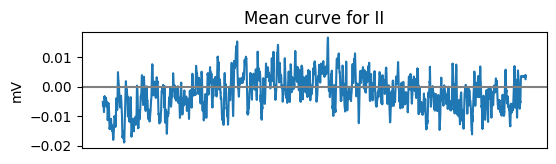

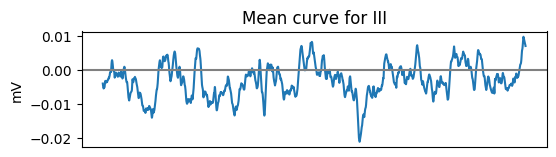

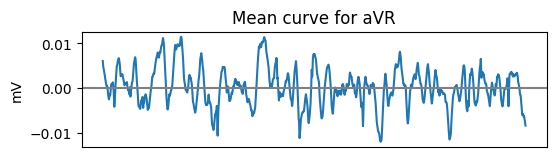

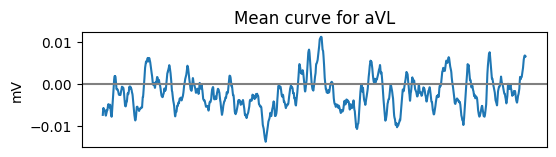

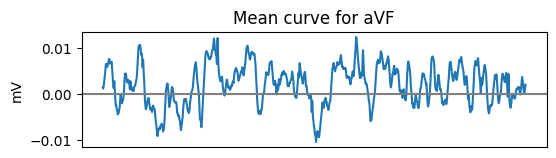

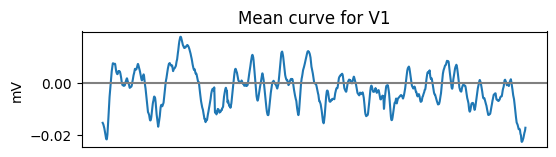

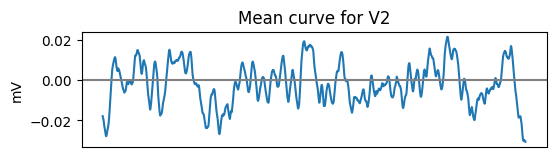

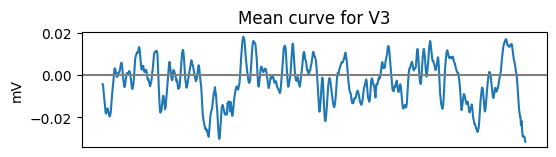

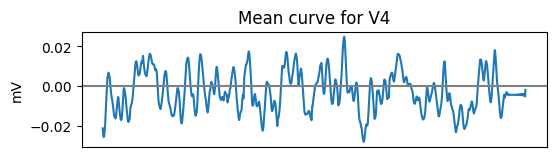

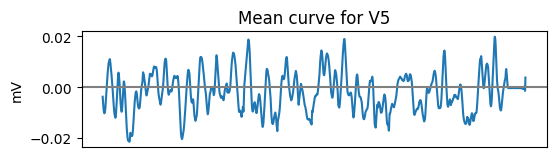

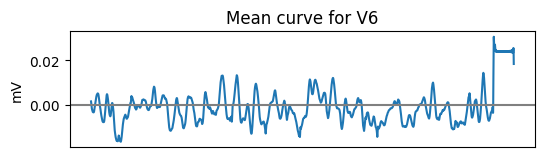

In [6]:
def fit_mean_model(train, verbose=False):
    """Compute minima, maxima and means of the time series"""
    mean_dict = defaultdict(list)
    for idx, row in tqdm(train.iterrows(), total=len(train)):
        labels = label_dict[idx]
        for lead in labels.columns:
            values = labels[lead]
            values = values[~values.isna()]
            mean_dict[lead].append(values)
    
    for lead in mean_dict.keys():
        # Upsample every time series to 20000 samples
        mean_dict[lead] = [
            np.interp(np.linspace(0, len(values)-1, 20000), np.arange(len(values)), values)
            for values in mean_dict[lead]
        ]

        # Stack all ECGs
        mean_dict[lead] = np.stack(mean_dict[lead])

        # Plot the mean ECG
        if verbose:
            m = mean_dict[lead].mean(axis=0)
            # s = mean_dict[lead].std(axis=0)
            plt.figure(figsize=(6, 1.5))
            plt.title(f"Mean curve for {lead}")
            plt.plot(m)
            # plt.plot(m-s/30)
            # plt.plot(m+s/30)
            plt.axhline(0, color='gray')
            plt.ylabel('mV')
            plt.gca().get_xaxis().set_visible(False)
            plt.show()

    return mean_dict

def validate_mean_model(val, mean_dict):
    snr_list = []
    for idx, row in tqdm(val.iterrows(), total=len(val)):
        labels = label_dict[idx]
        # Evaluate the signal-to-noise ratio
        sum_signal = 0
        sum_noise = 0
        for lead in labels.columns:
            label = labels[lead]
            label = label[~ label.isna()]
            pred = mean_dict[lead].mean(axis=0)
            pred = np.interp(np.linspace(0, 1, len(label)), np.linspace(0, 1, len(pred)), pred)
            assert len(label) == len(pred)
    
            aligned_pred = align_signals(label, pred, int(row.fs * MAX_TIME_SHIFT))
            p_signal, p_noise = compute_power(label, aligned_pred)
            sum_signal += p_signal
            sum_noise += p_noise
    
        snr = compute_snr(sum_signal, sum_noise)
        snr_list.append(snr)
    
    snr = np.array(snr_list).mean()
    val_score = max(float(10 * np.log10(snr)), -PERFECT_SCORE)
    print(f"# Validation SNR for mean prediction: {snr:.2f} {val_score=:.2f}")

# # Validate the mean model
# train_test_split_loc = 780
# mean_dict = fit_mean_model(train.iloc[:train_test_split_loc], verbose=True)
# validate_mean_model(train.iloc[train_test_split_loc:], mean_dict)

# Refit the mean model to the full dataset
mean_dict = fit_mean_model(train, verbose=True)


# Finding lead endpoints with MarkerFinder

Before decoding an image, it's good to know the coordinates of the 17 lead endpoints in the ECG. The following cell defines the class `MarkerFinder`, which determines these points. 13 points are found by the pattern matching function `cv2.matchTemplate()`; the right endpoints of the four lines are inferred as linear combinations of the other vectors.

In [7]:
class MarkerFinder:
    """This class finds the 13 markers in scanned ecg images and guesses the 4 line ends."""
    # From https://www.kaggle.com/code/ambrosm/ecg-original-explained-baseline
    
    def __init__(self, show_templates=False):
        # Derive the templates from type 1 images
        # np.max keeps the gridlines and markers and removes the ecg lines
        ima = np.max([
            cv2.imread('/kaggle/input/physionet-ecg-image-digitization/train/4292118763/4292118763-0001.png'),
            cv2.imread('/kaggle/input/physionet-ecg-image-digitization/train/4289880010/4289880010-0001.png'),
            cv2.imread('/kaggle/input/physionet-ecg-image-digitization/train/4284351157/4284351157-0001.png'),
        ], axis=0)

        # Template points in global coordinates of type 1 images
        absolute_points = np.zeros((17, 2), dtype=int)
        for i in range(3):
            absolute_points[5 * i] = np.array([707 + 284 * i, 118]) # y, x
            for j in range(1, 5):
                absolute_points[5 * i + j] = np.array([707 + 284 * i, 118 + 492 * j])
        absolute_points[5 * 3] = np.array([1535, 118])
        absolute_points[5 * 3 + 1] = np.array([1535, 118 + 492 * 4])

        # Top left corner of template rectangle
        template_positions = [None] * 17
        for i in range(len(absolute_points)):
            if absolute_points[i][1] < 118 + 492 * 4:
                if i % 5 == 0:
                    template_positions[i] = (absolute_points[i][0] - 87, absolute_points[i][1] - 50) # y, x
                else:
                    template_positions[i] = (absolute_points[i][0] - 37, absolute_points[i][1] - 13)

        # Height and width of the templates
        template_sizes = np.array([(105, 60)] * 17) # height, width

        # Transform the points to relative coordinates (inside the template)
        template_points = [np.array([absolute_points[i][0] - template_positions[i][0],
                                     absolute_points[i][1] - template_positions[i][1]])
                           if template_positions[i] is not None
                           else None
                           for i in range(len(absolute_points))]

        # Save the template matrices
        templates = [None] * 17
        for i in range(len(template_positions)):
            if template_points[i] is not None:
                template = (ima[template_positions[i][0]:template_positions[i][0]+template_sizes[i][0],
                            template_positions[i][1]:template_positions[i][1]+template_sizes[i][1]])
                templates[i] = template

        # Plot the template matrices
        if show_templates:
            _, axs = plt.subplots(4, 4, figsize=(5, 7))
            for i in range(len(template_positions)):
                if template_points[i] is not None:
                    template = templates[i].copy()
                    cv2.rectangle(template,
                                  (template_points[i][1]-1, template_points[i][0]-1),
                                  (template_points[i][1]+1, template_points[i][0]+1), 
                                  [255, 0, 0], 2)
                    axs[i // 5, i % 5].imshow(template)
            for i in range(13, len(axs.ravel())):
                axs.ravel()[i].axis('off')
            plt.tight_layout()
            plt.suptitle('The templates for the 13 markers', y=1.01)
            plt.show()

        self._absolute_points = absolute_points
        self._template_positions = template_positions
        self._template_sizes = template_sizes
        self._template_points = template_points
        self._templates = templates
        
    def find_markers(self, ima, warn=False, plot=False, title=''):
        """Return 17 markers as list of size-2 integer arrays (row, column)

        Parameters:
        ima: array of shape (1652, height, 3)
        """
        
        if ima.shape[0] != 1652:
            raise ValueError("Implemented only for scanned images (image types 3, 4, 11, 12)")

        markers = np.full((17, 2), -1)

        # Find 13 template-based markers
        for j in range(len(self._templates)):
            if self._template_points[j] is not None:
                t = self._template_positions[j][0]-100
                l = max(self._template_positions[j][1]-100, 0)
                search_range = (ima[t:self._template_positions[j][0]+100+self._template_sizes[j][0],
                                l:self._template_positions[j][1]+250+self._template_sizes[j][0]])
                res = cv2.matchTemplate(search_range, self._templates[j], cv2.TM_CCOEFF)
                min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)
    
                top_left = max_loc
                if warn and max_val < 3e7:
                    bottom_right = (top_left[0] + self._templates[j].shape[1],
                                    top_left[1] + self._templates[j].shape[0])
                    print(j, top_left, max_val)
                    search_range = search_range.copy()
                    cv2.rectangle(search_range, top_left, bottom_right, 0, 2)
                    plt.imshow(search_range)
                    plt.show()
                markers[j] = np.array((t + top_left[1] + self._template_points[j][0],
                                       l + top_left[0] + self._template_points[j][1]))

        # Guess the ends of the first three lines (can be outside the bounding box of the image)
        for i in range(3):
            m = markers[5 * i + 3] * 2 - markers[5 * i + 2]
            markers[5 * i + 4] = m

        # Guess the end of the fourth line (can be outside the bounding box of the image)
        markers[16] = ((markers[14] * (284 + 260) - markers[9] * 260) / 284).astype(int)

        if plot:
            ima = ima.copy()
            for m in markers:
                if m is not None:
                    cv2.rectangle(ima, (m[1]-40, m[0]-40), (m[1]+40, m[0]+40), (255, 0, 0), 2)
            # plt.figure(figsize=(12, 8))
            plt.imshow(ima)
            plt.title(title)
            plt.show()

        return markers

    # def baseline(self, i):
    #     """y coordinate of ith baseline in type 1 images"""
    #     if i not in [0, 1, 2, 3]:
    #         raise ValueError("i must be in [0, 1, 2, 3]")
    #     return self._absolute_points[5 * i][0]
        
    @staticmethod
    def lead_info(lead):
        """Specify which markers mark the begin and the end of a lead."""
        begin, end = {
            'I': (0, 1),
            'II-subset': (5, 6),
            'III': (10, 11),
            'aVR': (1, 2),
            'aVL': (6, 7),
            'aVF': (11, 12),
            'V1': (2, 3),
            'V2': (7, 8),
            'V3': (12, 13),
            'V4': (3, 4),
            'V5': (8, 9),
            'V6': (13, 14),
            'II': (15, 16),
        }[lead]
        return begin // 5, begin, end

    def demo(self, ima, warn=False, title=''):
        """Plot the image with red markers"""
        markers = self.find_markers(ima, warn, plot=True, title=title)

mf = MarkerFinder(show_templates=False)

print('MarkerFinder ready.')

MarkerFinder ready.


# Solution 1: A plane sweep for digitizing scanned color images

We define the function `convert_scanned_color()`, which converts an image to twelve time series. This function fulfills the main task of the competition, but it works only for images of types 3 and 11. It does not yet generalize to images with a black grid in the background or to mobile photos.

The algorithm sweeps the image from top to bottom. The first black pixels detected during the sweep define the first line. The sweep continues over the white pixels below the line, and the next black pixels define the second line. An so on for the third and fourth line.

After we have the four lines, we use the markers found by `MarkerFinder` to select the segments which form the 12 leads.

And why did I choose types 3 and 11? For two reasons: First, the scanned images have higher quality than the mobile photos, and they always have the same scale (80 pixels per mV). Second, the color makes it easy to distinguish the black ECG lines from the red gridlines.



In [8]:
def find_line_by_topdown_sweep(ima):
    """Find the topmost black line in an image and remove it.

    Parameters:
    ima: 2d boolean image array (False = black, True = white), will be updated

    Return values:
    top: topmost black pixel in every column of the matrix
    bottom: topmost white pixel in every column of the matrix below the topmost black pixel
    """
    # Find the topmost black pixels
    top = np.argmin(ima, axis=0) # topmost black (False) pixel per column; 0 if there are no black pixels

    # Extend into columns without black pixels
    median_top = int(np.median(top))
    top[top == 0] = median_top
    top[top > median_top + 250] = median_top
    
    # Bound from above
    strip_width = 64
    for strip_left in range(0, ima.shape[1], strip_width):
        median_top_strip = int(np.median(top[strip_left:strip_left+strip_width]))
        strip = ima[:median_top_strip-100, strip_left:strip_left+strip_width]
        all_white = strip.all(axis=1)
        if all_white.size > 0:
            first_white_row = np.argmax(all_white[::-1])
            if first_white_row > 0 or all_white[-1]:
                first_white_row = median_top_strip - 100 - first_white_row
                ami = np.argmin(ima[first_white_row:, strip_left:strip_left+strip_width], axis=0)
                top[strip_left:strip_left+strip_width] = np.where(ami != 0, first_white_row + ami, median_top)
    top[top > median_top + 250] = median_top

    # Bound from below
    strip_width = 64
    for strip_left in range(0, ima.shape[1], strip_width):
        median_top_strip = int(np.median(top[strip_left:strip_left+strip_width]))
        strip = ima[median_top_strip+80:, strip_left:strip_left+strip_width]
        all_white = strip.all(axis=1)
        if all_white.size > 0:
            first_white_row = np.argmax(all_white)
            if first_white_row > 0 or all_white[0]:
                first_white_row += median_top_strip + 80
                mask = top > first_white_row
                mask[:strip_left] = False
                mask[strip_left+strip_width:] = False
                top[mask] = median_top_strip

    # Paint black everything above
    mask = np.tile(np.arange(len(ima)).reshape(-1, 1), reps=(1, ima.shape[1]))
    mask = mask >= top # True for lower part of image
    ima &= mask # paint black whatever is above the line

    # Find the topmost white pixels
    bottom = np.argmax(ima, axis=0) # topmost white (True) pixel per column; 0 if there are no white pixels

    # Paint white everything above
    bottomx = np.maximum(bottom, np.median(top) + 100) # overpaints the letters
    mask = np.tile(np.arange(len(ima)).reshape(-1, 1), reps=(1, ima.shape[1]))
    mask = mask < bottomx # True for upper part of image
    ima |= mask # paint white whatever is above the line
    ima[:,:-1] |= mask[:,1:]
    ima[:,1:] |= mask[:,:-1]

    return top, bottom

def get_lead_from_top_bottom(tops, bottoms, lead, n_timesteps, markers):
    """Extract and resample one lead from an ECG line.
    
    Parameters:
    tops: list of 4 arrays of shape (image_width, )
    bottoms: list of 4 arrays of shape (image_width, )
    lead: one of the 12 lead labels (string)
    n_timesteps: number of samples required (int)
    markers: 17 markers as list of size-2 integer arrays (row, column)
    """

    # Select the markers and determine the baseline
    line, begin, end = mf.lead_info(lead)
    top = tops[line]
    bottom = bottoms[line]
    begin, end = markers[begin], markers[end]
    baseline = np.linspace(begin[0], end[0], end[1] - begin[1])
    
    pred0 = (top[begin[1]:end[1]] + bottom[begin[1]:end[1]]) / 2
    baseline = baseline[:len(pred0)] # in case end is outside the image (only idx 202 and some test)
    pred = baseline - pred0

    # Scale
    pred /= 80 # 80 pixels = 1 mV

    # Fix pixels obscured by the markers
    if lead in ['aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']:
        # first four pixels can be obscured by the marker
        pred[:4] = np.where(pred[:4] > 0.2, pred[4], pred[:4])
    if lead in ['I', 'II-subset', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3']:
        # last five pixels can be obscured by the marker
        pred[-5:] = np.where(pred[-5:] > 0.2, pred[-6], pred[-5:])
    if lead in ['I', 'II-subset', 'III', 'II']:
        # first two pixels can be obscured by the marker
        pred[:2] = pred[2]

    # Upsample
    pred = np.interp(np.linspace(0, 1, n_timesteps),
                     np.linspace(0, 1, len(pred)),
                     pred)

    # Fix implausible predictions
    # From https://www.kaggle.com/code/antonoof/large-eda-and-statistical-model
    OUTLIER_LOW_THRESHOLD = -1.5
    OUTLIER_HIGH_THRESHOLD = 0.9
    outlier_mask = (pred < OUTLIER_LOW_THRESHOLD) | (pred > OUTLIER_HIGH_THRESHOLD)
    if np.any(outlier_mask):
        for i in np.where(outlier_mask)[0]:
            start_idx = max(0, i - 3)
            end_idx = min(len(pred), i + 4)
            neighbors = pred[start_idx:end_idx]
            valid_neighbors = neighbors[(neighbors >= OUTLIER_LOW_THRESHOLD) & (neighbors <= OUTLIER_HIGH_THRESHOLD)]
            if len(valid_neighbors) > 0:
                pred[i] = np.median(valid_neighbors)
            else:
                pred[i] = 0

    # Median filter proposed by @guntasdhanjal
    pred = medfilt(pred, kernel_size=5)

    return pred

def convert_scanned_color(ima, markers, n_timesteps, verbose=False):
    """Convert a scanned color image (type 3 or 11) to 12 leads.

    The function first extracts the four lines from the image. As
    the four lines have nonnegligible width, we construct two lists:
    - tops = y coordinates of the topmost black pixels in the lines
    - bottoms = y coordinates of the topmost white pixels below the lines
    Either list is a list of 4 arrays of shape (image_width, )

    Parameters:
    ima: 3-channel BGR image with height 1652 and width ≈2200.
    markers: 17 markers as list of size-2 integer arrays (row, column)
    n_timesteps: number of samples required per lead (dict)

    Returns:
    preds: dict with 12 time series
    """
    # Crop the image and convert to black and white
    # We use only the red channel (channel 2) so that the red gridlines disappear
    # False = black, True = white
    # The text at the top of the image is discarded.
    crop_top = 400
    ima = ima[crop_top:, :, 2] > 160

    # Denoise single and double black pixels
    iima = ima.astype(np.uint8)
    ima = (iima[:-2, :-2] + iima[:-2, 1:-1] + iima[:-2, 2:]
           + iima[1:-1, :-2] + iima[1:-1, 1:-1] + iima[1:-1, 2:]
           + iima[2:, :-2] + iima[2:, 1:-1] + iima[2:, 2:]) >= 7

    # Clean the bottom border
    baseline_II = markers[15:17][0].max() - crop_top
    all_white = ima[baseline_II:, markers[15][1]:markers[16][1]].all(axis=1)
    ama = np.argmax(all_white)
    if ama > 0 or all_white[0]:
        ima[baseline_II + ama:] = True
    
    # Plot the denoised black-and-white image
    if verbose:
        plt.figure(figsize=(6, 4))
        plt.imshow(ima)
        plt.title('Denoised black-and-white')
        plt.show()
        # cv2.imwrite('ima-bw.png', ima.astype(int) * 255)

    # Find the four lines
    tops, bottoms = [], []
    for i in range(4):
        top, bottom = find_line_by_topdown_sweep(ima)
        tops.append(top)
        bottoms.append(bottom)
    if verbose:
        left = max(markers[:, 1].min() - 80, 0)
        right = markers[:, 1].max() + 80
        _, axs = plt.subplots(4, 1, sharex=True, figsize=(12, 8))
        for i in range(4):
            for j in range(5):
                if 5*i+j < len(markers):
                    axs[i].axvline(markers[5*i+j][1], color='gray')
            axs[i].plot(np.arange(left, right), tops[i][left:right], color='b', label='top')
            axs[i].plot(np.arange(left, right), bottoms[i][left:right], color='m', label='bottom')
            axs[i].invert_yaxis()
            axs[i].set_ylabel('pixel')
            axs[i].legend()
            axs[i].set_title(f"Extracted line {i}")
        plt.show()

    # Transform to global coordinates
    tops = [t + crop_top for t in tops]
    bottoms = [b + crop_top for b in bottoms]

    # Extract the twelve leads from the four lines
    # (as the first part of II is duplicated, we extract it twice
    # and take the average)
    n_timesteps['II-subset'] = n_timesteps['I']
    preds = {}
    for i, lead in enumerate(LEADS + ['II-subset']):
        pred = get_lead_from_top_bottom(tops, bottoms, lead, n_timesteps[lead], markers)
        preds[lead] = pred

    preds['II'][:len(preds['II-subset'])] = (preds['II'][:len(preds['II-subset'])] + preds['II-subset']) / 2
    del preds['II-subset']

    # Apply Einthoven's law
    apply_einthoven(preds)

    return preds

def apply_einthoven(preds):
    """Apply Einthoven's law to improve the predictions.

    The three equalities are
    I + III - II = 0
    aVR + avL + aVF = 0
    2 * aVR - 2 * aVF + 3 * II = 0
    
    Parameters:
    pred: dict of time series, will be updated
    """
    residual = preds['I'] + preds['III'] - preds['II'][:len(preds['III'])]
    correction = residual / 3
    preds['I'] -= correction
    preds['III'] -= correction
    preds['II'][:len(preds['III'])] += correction
    
    residual = preds['aVR'] + preds['aVL'] + preds['aVF']
    correction = residual / 3
    preds['aVR'] -= correction
    preds['aVL'] -= correction
    preds['aVF'] -= correction

    residual = 2 * preds['aVR'] - 2 * preds['aVF'] + 3 * preds['II'][len(preds['I']):len(preds['I'])+len(preds['aVR'])]
    correction = residual / 17
    preds['aVR'] -= 2 * correction
    preds['aVF'] += 2 * correction
    preds['II'][len(preds['I']):len(preds['I'])+len(preds['aVR'])] -= 3 * correction


## Validation of solution 1

We digitize a few training images, plot the output and compute the signal-to-noise ratio. 

If you look at the diagrams closely, you'll easily get ideas for improvements. The diagrams show:
1. The original image
2. The denoised image
3. Four extracted ECG lines
4. y_true vs. y_pred

Validation is important: If you only get feedback from five submissions per day, your progress will be much too slow.

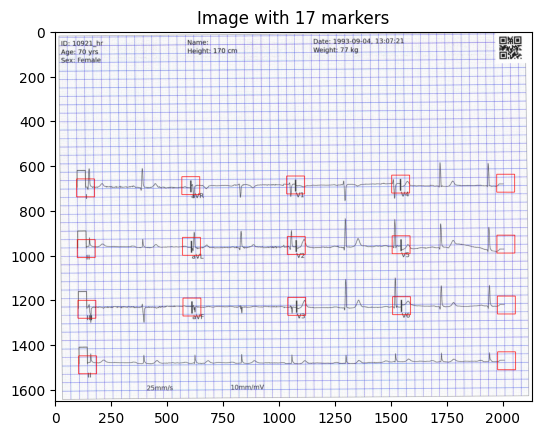

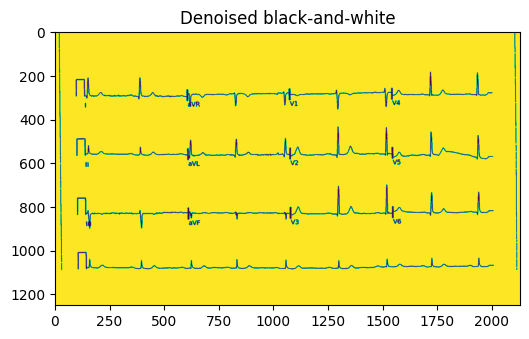

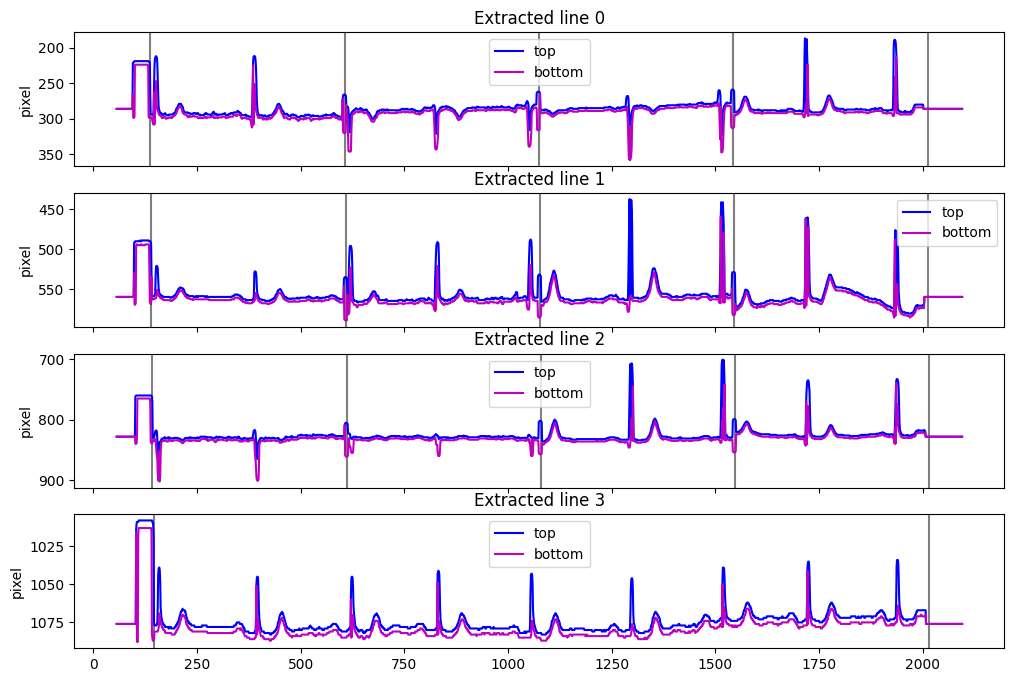

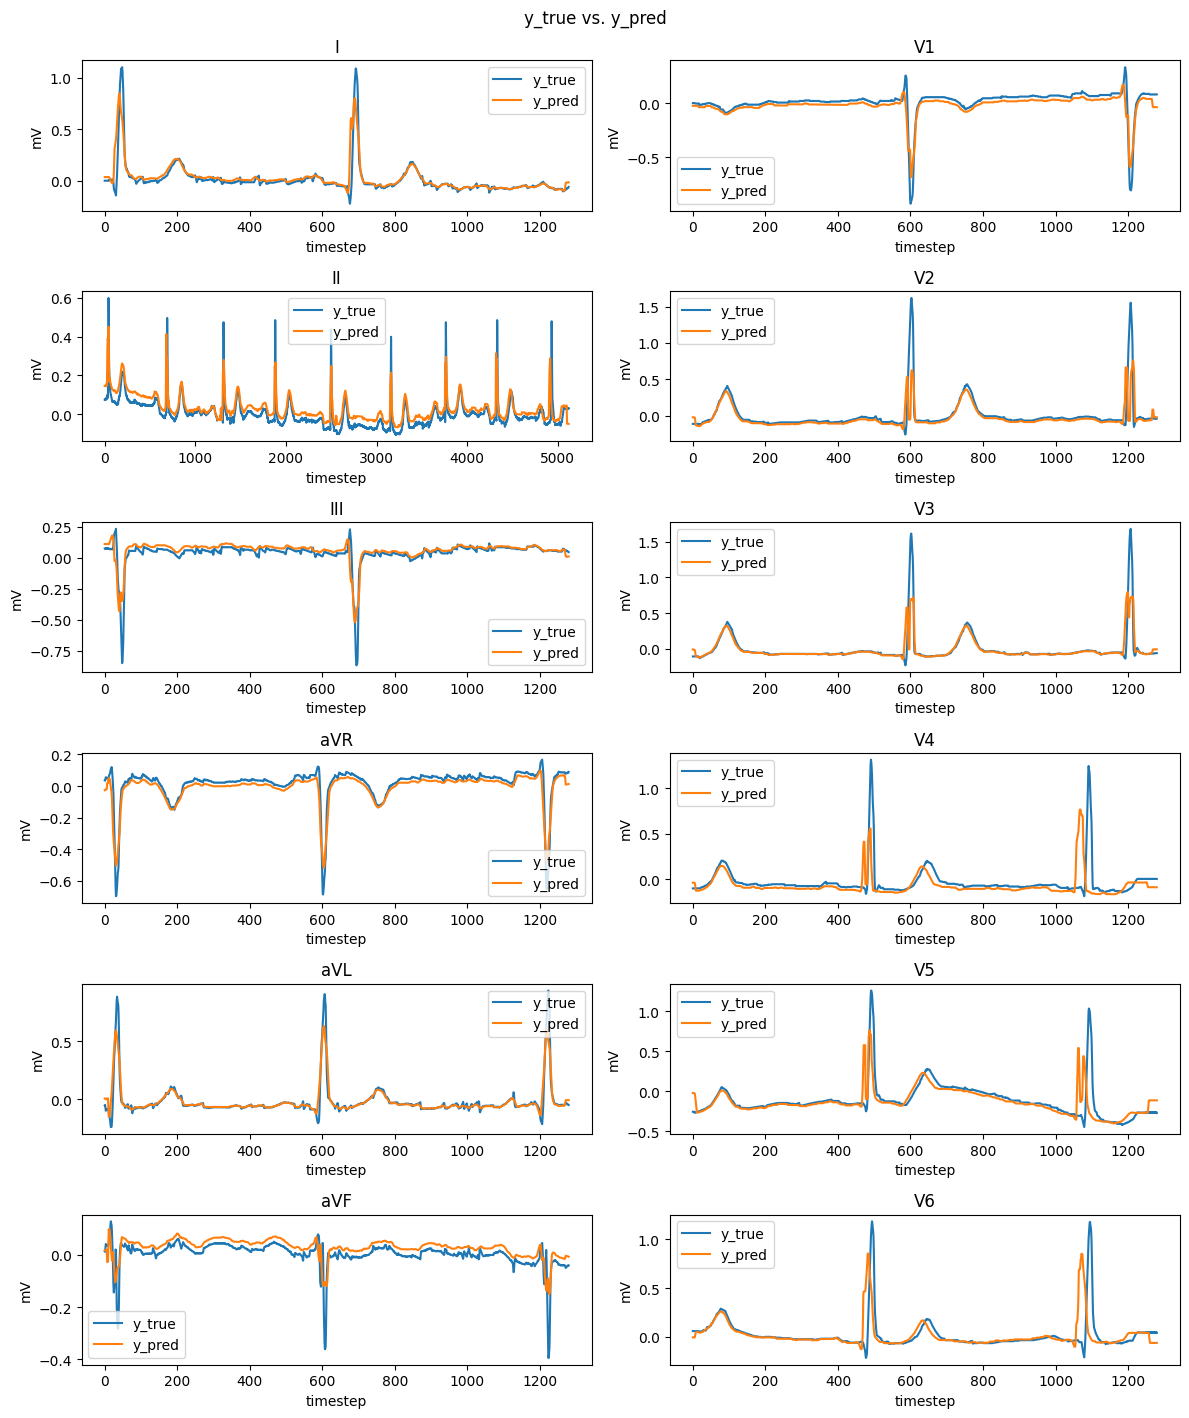

idx= 400 img_type= 3 SNR:  3.06


idx= 400 img_type=11 SNR:  2.71
idx= 401 img_type= 3 SNR:  2.52
idx= 401 img_type=11 SNR:  2.15
idx= 402 img_type= 3 SNR:  5.47
idx= 402 img_type=11 SNR:  6.63
idx= 403 img_type= 3 SNR:  4.10
idx= 403 img_type=11 SNR:  0.53
idx= 404 img_type= 3 SNR:  2.11
idx= 404 img_type=11 SNR:  1.77
idx= 405 img_type= 3 SNR:  3.12
idx= 405 img_type=11 SNR:  2.43
idx= 406 img_type= 3 SNR:  3.27
idx= 406 img_type=11 SNR:  3.57
idx= 407 img_type= 3 SNR:  1.85
idx= 407 img_type=11 SNR:  2.15
idx= 408 img_type= 3 SNR:  2.79
idx= 408 img_type=11 SNR:  2.44
idx= 409 img_type= 3 SNR:  3.16
idx= 409 img_type=11 SNR:  3.20
2.9516554737893226 20
# Average SNR: 1.43 val_score=1.56 [3, 11]


In [9]:
def validate_algorithm(convert, start=None, end=None, image_types=None):
    """Convert a few training images, plot the output and compute the signal-to-noise ratio"""
    if len(test) != 24:
        # test file when saving has 2*12=24 rows
        return # when submitting, nobody will see the validation output
    snr_list = []
    index_list = []
    is_first_ecg = True # we plot only the images of the first ECG
    for idx, ima, img_type, labels in train_images_and_labels(start=start,
                                                              end=end,
                                                              image_types=image_types,
                                                              use_tqdm=False):

        # Find the 17 line endpoints
        markers = mf.find_markers(ima, plot=is_first_ecg, title='Image with 17 markers')

        # Convert the image to 12 leads
        n_timesteps = {lead: (~ labels[lead].isna()).sum() for lead in LEADS}
        preds = convert(ima, markers, n_timesteps, verbose=is_first_ecg)
        
        # Evaluate the signal-to-noise ratio, plot y_true vs. y_pred
        if is_first_ecg:
            _, axs = plt.subplots(6, 2, figsize=(12, 14))
        sum_signal = 0
        sum_noise = 0
        for i, lead in enumerate(LEADS):
            label = labels[lead]
            label = label[~ label.isna()]
            pred = preds[lead]
    
            aligned_pred = align_signals(label, pred, int(row.fs * MAX_TIME_SHIFT))
            p_signal, p_noise = compute_power(label, aligned_pred)
            sum_signal += p_signal
            sum_noise += p_noise

            if is_first_ecg:
                ax = axs.T.ravel()[i]
                ax.set_title(lead)
                ax.plot(label.values, label='y_true')
                ax.plot(pred, label='y_pred')
                ax.set_xlabel('timestep')
                ax.set_ylabel('mV')
                ax.legend()
        if is_first_ecg:
            plt.tight_layout()
            plt.suptitle('y_true vs. y_pred', y=1.01)
            plt.show()
        snr = compute_snr(sum_signal, sum_noise)
        print(f"{idx=:4d} {img_type=:2d} SNR: {snr:5.2f}")
        snr_list.append(snr)
        index_list.append([idx, img_type])

        if is_first_ecg:
            print('\n')
            is_first_ecg = False

    print(np.array(snr_list).mean(), len(snr_list))
    snr = (np.array(snr_list).mean() - 1) / 9 * len(image_types) + 1
    val_score = max(float(10 * np.log10(snr)), -PERFECT_SCORE)
    print(f"# Average SNR: {snr:.2f} {val_score=:.2f} {image_types}")
    snr_df = pd.DataFrame(index_list, columns=['idx', 'type'])
    snr_df['snr'] = snr_list
    snr_df.to_csv('snr_baseline.csv', index=False)

validate_algorithm(convert_scanned_color, start=400, end=410, image_types=[3, 11])


# Solution 2: A neural network for digitizing grayscale images

Plane sweep is a nice algorithm, but it fails when the image is too noisy. It can't even deal with black gridlines. So how can we transform this ECG image digitization competition into a tractable regression task?

Thanks to the `MarkerFinder` class, we know where the ECG lines begin and end, and we can even map the true labels to pixels of the image. We now slice the image between these markers into thin vertical stripes (600 pixels high, 11 pixels wide). The ECG lines intersect the stripes at a certain height, and predicting this height is a regression task.

Look at the diagram below, which shows some random stripes. The regression targets (numbers between 0 and 600) are shown above every stripe. Try to discern the following items:
1. ECG lines intersecting the stripe (the stripes are high enough so that there is often more than one line, one of them should be at the position indicated at the top of the diagram)
2. horizontal gridlines
3. vertical gridlines
4. markers showing the start of a lead
5. lead designations (letters 'a' and 'V')
6. other noise

The size of the stripes (600\*11 = 6600 pixels) has been chosen so that the neural network (with 6600 inputs and one output) can be trained easily in Kaggle notebooks.

## Preparing the training data

We put the training data into arrays X of shape (40000, 6600) and y of shape (40000, ).

In [10]:
# Preparing the training data
n_train_nn, n_training_samples_per_line = 40000, 30
h0, w0 = 600, 11

X = np.zeros((n_train_nn, h0 * w0), dtype=np.float32)
y = np.zeros((n_train_nn, ), dtype=np.float32)

def prepare_dataset(train):
    i_train_nn = 0
    rng = np.random.default_rng(1)
    t = tqdm(total=n_train_nn, position=0)
    for idx, row in train.iterrows():
        labels = pd.read_csv(f'/kaggle/input/physionet-ecg-image-digitization/train/{row.id}/{row.id}.csv')
        png_paths = sorted(glob(f'/kaggle/input/physionet-ecg-image-digitization/train/{row.id}/{row.id}-*.png'))
        for path in png_paths:
            img_type = int(path[-8:-4])
            if img_type in [4, 12]:
                ima = cv2.imread(path)
                markers = mf.find_markers(ima)
                ima = ima.mean(axis=2)
                ll = np.array([labels['aVR'].fillna(0) + labels['V1'].fillna(0),
                               labels['aVL'].fillna(0) + labels['V2'].fillna(0),
                               labels['aVF'].fillna(0) + labels['V3'].fillna(0),])
                for i in range(3):
                    for j in range(1, 3):
                        yl, xl = markers[5*i+j]
                        yp, xp = markers[5*i+j+1] - markers[5*i+j]
                        lead = ['', 'aVR', 'V1', '', '', '', 'aVL', 'V2', '', '', '' ,'aVF', 'V3'][5*i+j]
                        l = labels[lead]
                        l = l[~l.isna()]
                        l = np.interp(np.linspace(0, 1, xp),
                                      np.linspace(0, 1, len(l)),
                                      l) * 80 # true labels in pixel coordinates
                        assert xp > 0 # yp may be negative
                        for k in range(n_training_samples_per_line):
                            alpha = rng.uniform()
                            x0, y0 = int(xl + alpha * xp), int(yl + alpha * yp)
                            X[i_train_nn] = ima[y0-h0//2:y0+h0//2, x0-w0//2:x0+w0//2+1].ravel()
                            y[i_train_nn] = h0 / 2 - l[x0-xl]
                            i_train_nn += 1
                            t.update(1)
                            if i_train_nn == n_train_nn:
                                t.close()
                                print(f"last idx used: {idx}")
                                return
        
prepare_dataset(train.iloc[200:])
print(X.shape, y.shape, X.size*4) # (n_train_nn, w0*h0) (n_train_nn, ) 40000 -> last idx used: 311
X_orig = X.copy()
X = X / 255.0 - 1 # offset so that X.max() = 0
assert np.isfinite(X).all()
assert np.isfinite(y).all()

# X is a scaled pixel intensity, 0 = white, -1 = black
# y is amplitude in pixels, usually between 0 and h0-1, h0//2 is baseline. In rare cases it is below 0 or above h0

100%|██████████| 40000/40000 [01:25<00:00, 466.94it/s]


last idx used: 311
(40000, 6600) (40000,) 1056000000


## The network

We implement a neural network with four hidden layers (7 million parameters) and train it. If everything goes well, the R2 score should be about 0.75, corresponding to a signal-to-noise ratio of 4. Feel free to experiment with other network architectures.

In [11]:
def regression_model():
    """A dense feed-forward with 4 hidden layers."""
    initial_lr = 0.005
    noise = 0.3
    x_input = Input(shape=(X.shape[-1], ))
    x = x_input
    x = GaussianNoise(noise)(x)
    x = Dense(units=1024, activation='selu')(x)
    x = Dense(units=512, activation='selu')(x)
    x = Dense(units=256, activation='selu')(x)
    x = Dense(units=256, activation='selu')(x)
    x_output = Dense(units=1, activation='linear', bias_initializer=Constant(h0 / 2))(x)

    model = Model(inputs=x_input, outputs=x_output)
    return model, initial_lr

model, _ = regression_model()
model(X[0:5]).shape
model.summary()

I0000 00:00:1773840463.841288      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 6600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     6,759,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,481,601 (28.54 MB)

 Trainable params: 7,481,601 (28.54 MB)

 Non-trainable params: 0 (0.00 B)

317.95746
Epoch 1/70


I0000 00:00:1773840469.297907     104 service.cc:148] XLA service 0x7e2d5000c810 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773840469.298678     104 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773840469.519550     104 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1773840470.681651     104 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


500/500 - 6s - 12ms/step - loss: 329.3053 - val_loss: 224.2574 - learning_rate: 0.0050
Epoch 2/70
500/500 - 2s - 4ms/step - loss: 177.0110 - val_loss: 150.0007 - learning_rate: 0.0050
Epoch 3/70
500/500 - 2s - 4ms/step - loss: 164.7733 - val_loss: 181.2366 - learning_rate: 0.0050
Epoch 4/70

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.
500/500 - 2s - 4ms/step - loss: 135.4461 - val_loss: 157.0247 - learning_rate: 0.0050
Epoch 5/70
500/500 - 2s - 4ms/step - loss: 100.6492 - val_loss: 116.5408 - learning_rate: 0.0025
Epoch 6/70
500/500 - 2s - 4ms/step - loss: 83.4896 - val_loss: 123.3468 - learning_rate: 0.0025
Epoch 7/70
500/500 - 2s - 4ms/step - loss: 67.7194 - val_loss: 100.9534 - learning_rate: 0.0025
Epoch 8/70
500/500 - 2s - 4ms/step - loss: 57.2619 - val_loss: 109.2386 - learning_rate: 0.0025
Epoch 9/70

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0012499999720603228.
500/500 - 2s - 4ms/step - loss: 53.2314 - val_loss: 107.1768 - learning_

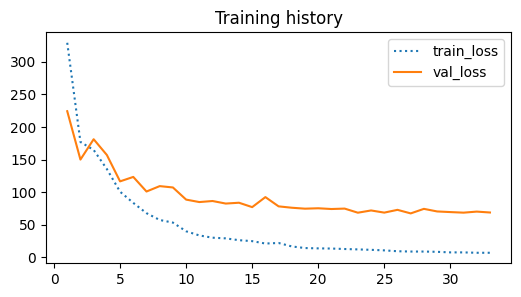

# Fold 0  68.75 0.78 317.96 40000*600*11 64



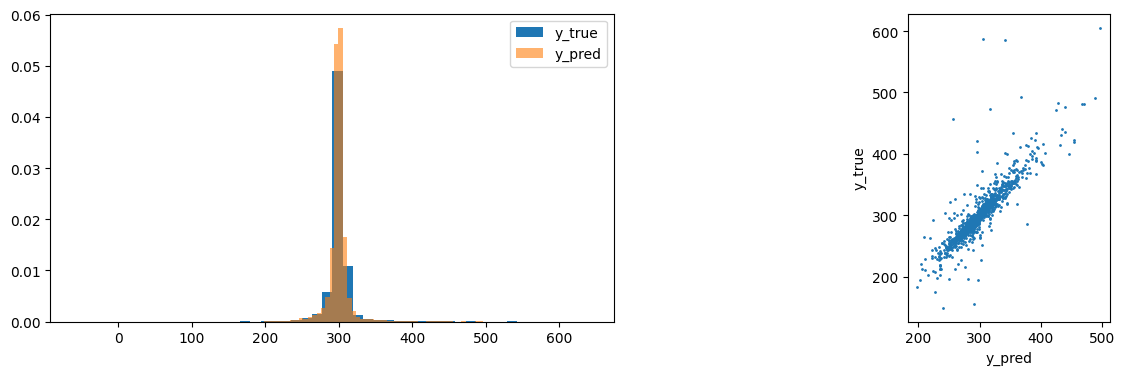

In [12]:
# Train the regression model
# Inputs for training: X and y
epochs = 70
verbose = 2
batch_size = 64

grayscale_model_list = []
oof = np.zeros_like(y)
kf = KFold(shuffle=True, random_state=1)
for fold, (idx_tr, idx_va) in enumerate(kf.split(X)):
    X_tr = X[idx_tr]
    X_va = X[idx_va]
    y_tr = y[idx_tr]
    y_va = y[idx_va]

    model, initial_lr = regression_model()

    # Train the complete model
    model.compile(
        optimizer=Adam(learning_rate=initial_lr),
        loss=MeanSquaredError(),
    )
    print(y_va.var())
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[EarlyStopping(patience=6, min_delta=0.1),
                   ReduceLROnPlateau(factor=0.5, patience=2, verbose=1, min_delta=0.1, min_lr=initial_lr/63),
                   TerminateOnNaN()],
        verbose=verbose
    )
    history = history.history
    plot_training_history(history)

    y_pred = model.predict(X_va, batch_size=1024, verbose=0).ravel()
    oof[idx_va] = y_pred
    mse = np.square(y_va - y_pred).mean()
    r2 = r2_score(y_va, y_pred)
    print(f'# Fold {fold} {mse:6.2f} {r2:4.2f} {np.var(y_va):6.2f} {len(X)}*{h0}*{w0} {batch_size}\n')
    grayscale_model_list.append(model)

    # Regression
    plt.figure(figsize=(16, 4))
    plt.subplot(1, 2, 1)
    plt.hist(y, bins=50, density=True, label='y_true')
    plt.hist(y_pred, bins=50, density=True, alpha=0.6, label='y_pred')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.scatter(y_pred, y_va, s=1)
    plt.xlabel('y_pred')
    plt.ylabel('y_true')
    plt.gca().set_aspect('equal')
    plt.show()
    break

# Fold 0  75.41 0.76 317.96 *Model 0 initial_lr=0.005 noise=0.3* 40000*600*11 64

In [13]:
del X, y

## Validation of solution 2

We've used train.iloc\[200:\] to train the neural network. Consequently, we may use train.iloc\[:200\] for validating. We process a few images and evaluate the signal-to-noise ratio. 

By the way, the grayscale model works for color images, too, so that we can ensemble the neural network predictions with the plane sweep predictions.

In [14]:
def get_grayscale_lead(ima, lead, n_timesteps, markers):
    """Extract and resample one lead from an ECG image.

    The function returns the time series if possible, or it gives up and returns None.
    
    Parameters:
    ima: single-channel (grayscale image)
    lead: one of the 12 lead labels (string)
    n_timesteps: number of samples required (int)
    markers: 17 markers as list of size-2 integer arrays (row, column)

    Returns:
    pred: either an array of shape (n_timesteps, ) or None
    """
    line, begin, end = mf.lead_info(lead)

    X_list = []
    width = markers[end][1] - markers[begin][1]
    slope = (markers[end][0] - markers[begin][0]) / width

    for x0 in range(markers[begin][1], markers[end][1]):
        y0 = int(markers[begin][0] + slope * (x0 - markers[begin][1]))
        X = ima[y0-h0//2:y0+h0//2, x0-w0//2:x0+w0//2+1]
        if X.size == 0:
            X = np.full((h0, w0), 255) # all white
        else:
            if X.shape[0] < h0:
                X = np.vstack([X, np.full((h0 - X.shape[0], X.shape[1]), 255)]) # pad bottom white
            if X.shape[1] < w0:
                X = np.hstack([X, np.full((X.shape[0], w0 - X.shape[1]), 255)]) # pad right white
        X_list.append(X)
    X = np.stack(X_list).reshape(len(X_list), -1).astype(np.float32)
    assert X.shape[1] == w0 * h0
    assert np.isfinite(X).all()

    X = X / 255.0 - 1

    pred = h0 / 2 - np.mean([model.predict(X, batch_size=1024, verbose=0).ravel() for model in grayscale_model_list], axis=0)

    # Scale
    pred /= 80 # 80 pixels = 1 mV

    # Upsample
    pred = np.interp(np.linspace(0, 1, n_timesteps),
                     np.linspace(0, 1, len(pred)),
                     pred)
    
    # Fix implausible predictions
    pred = np.where(np.abs(pred) <= 2, pred, 0)
        
    return pred


def convert_scanned_grayscale(ima, markers, n_timesteps, verbose=False):
    """Convert a scanned grayscale image (type 4 or 12) to 12 time series.

    Parameters:
    ima: 3-channel BGR image with height 1652 and width ≈2200.
    markers: 17 markers as list of size-2 integer arrays (row, column)
    n_timesteps: number of samples required per lead (dict)

    Returns:
    preds: dict with 12 time series or None
    """
    # Drop the color channels / convert to grayscale
    ima = ima.mean(axis=2)

    n_timesteps['II-subset'] = n_timesteps['I']
    preds = {}
    for i, lead in enumerate(LEADS + ['II-subset']):
        preds[lead] = get_grayscale_lead(ima, lead, n_timesteps[lead], markers)

    if preds['II'] is not None and preds['II-subset'] is not None:
        preds['II'][:len(preds['II-subset'])] = (preds['II'][:len(preds['II-subset'])] + preds['II-subset']) / 2
    elif preds['II-subset'] is not None:
        preds['II'] = np.zeros(n_timesteps['II'])
        preds['II'][:len(preds['II-subset'])] = preds['II-subset']
    del preds['II-subset']

    # Apply Einthoven's law
    apply_einthoven(preds)
    
    return preds

def convert_scanned_both(ima, markers, n_timesteps, verbose=False):
    """Convert a scanned color image (type 3 or 11) to 12 time series.

    This function ensembles the neural network with the plane sweep algorithm.

    Parameters:
    ima: 3-channel BGR image with height 1652 and width ≈2200.
    markers: 17 markers as list of size-2 integer arrays (row, column)
    n_timesteps: number of samples required per lead (dict)

    Returns:
    preds: dict with 12 time series or None
    """
    keys = list(n_timesteps.keys())
    pred1 = convert_scanned_grayscale(ima, markers, n_timesteps, verbose=False)
    pred2 = convert_scanned_color(ima, markers, n_timesteps, verbose=False)

    def ensemble_two(pred1, pred2):
        if pred1 is not None and pred2 is not None:
            return (pred1 + pred2) / 2
        if pred1 is not None:
            return pred1
        return pred2
        
    preds = {k: ensemble_two(pred1[k], pred2[k]) for k in keys}
    return preds


print('All digitizer functions ready.')


All digitizer functions ready.


In [15]:
def is_color_image(ima):
    """ Test if a 3-channel image has colors."""
    return ima.std(axis=2).mean() != 0

---
# Part 2 — Conditional Diffusion Model (cDDPM)
Load data, train model, then integrate with the baseline above.

**Files needed in `/kaggle/working/`:**
- `noisynew2.npy`
- `cleannew2.npy`
- `metadata2.csv`

Upload them via *Add Data → Your Work* before running.

In [16]:
# ============================================================
# CELL 1 — Imports
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from numpy.linalg import norm
from scipy.spatial.distance import cosine as scipy_cosine

torch.manual_seed(42)
np.random.seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Running on: {DEVICE}')

Running on: cuda


Loaded: noisy (500, 1250)  clean (500, 1250)
NaNs   — noisy: 0  clean: 0

Cosine similarity — mean: 0.9735  std: 0.0236  min: 0.8699
Baseline MSE (input vs clean): 0.01207


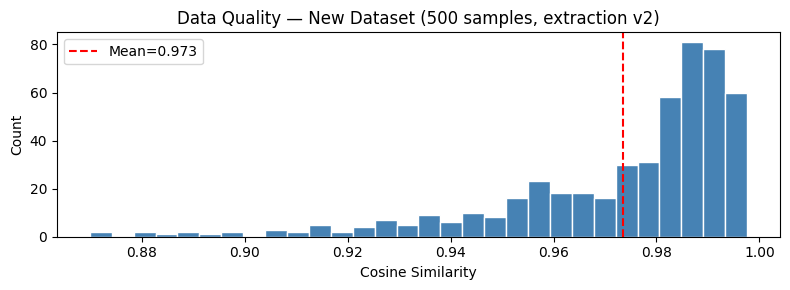

In [17]:
# ============================================================
# CELL 2 — Load data
# ============================================================
# ---- CHANGE PATHS IF NEEDED ----
FILE_NOISY = '/kaggle/input/datasets/mukulbamn/dm-ecg-digitizer-outputs/noisynew2.npy'
FILE_CLEAN = '/kaggle/input/datasets/mukulbamn/dm-ecg-digitizer-outputs/cleannew2.npy'
FILE_META  = '/kaggle/input/datasets/mukulbamn/dm-ecg-digitizer-outputs/metadata2.csv'
# --------------------------------

noisy_raw = np.load(FILE_NOISY).astype(np.float32)  # (500, 1250)
clean_raw = np.load(FILE_CLEAN).astype(np.float32)  # (500, 1250)
meta      = pd.read_csv(FILE_META)

print(f'Loaded: noisy {noisy_raw.shape}  clean {clean_raw.shape}')
print(f'NaNs   — noisy: {np.isnan(noisy_raw).sum()}  clean: {np.isnan(clean_raw).sum()}')

# Per-sample cosine similarity (already filtered >= 0.85 at extraction time)
cosines = np.array([
    np.dot(noisy_raw[i], clean_raw[i]) /
    (norm(noisy_raw[i]) * norm(clean_raw[i]) + 1e-8)
    for i in range(len(noisy_raw))
])

print(f'\nCosine similarity — mean: {cosines.mean():.4f}  '
      f'std: {cosines.std():.4f}  min: {cosines.min():.4f}')

# Baseline MSE (before any refinement)
baseline_mse = np.mean((noisy_raw - clean_raw)**2)
print(f'Baseline MSE (input vs clean): {baseline_mse:.5f}')

# Cosine distribution plot
plt.figure(figsize=(8, 3))
plt.hist(cosines, bins=30, color='steelblue', edgecolor='white')
plt.axvline(cosines.mean(), color='red', linestyle='--',
            label=f'Mean={cosines.mean():.3f}')
plt.xlabel('Cosine Similarity')
plt.ylabel('Count')
plt.title('Data Quality — New Dataset (500 samples, extraction v2)')
plt.legend()
plt.tight_layout()
plt.savefig('fig_data_quality_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ============================================================
# CELL 3 — Train / Validation split + DataLoaders
# ============================================================
# 80 / 20 split — lets us monitor generalization during training
N          = len(noisy_raw)
N_TRAIN    = int(0.8 * N)   # 400
N_VAL      = N - N_TRAIN    # 100

noisy_t = torch.FloatTensor(noisy_raw).unsqueeze(1)  # (500, 1, 1250)
clean_t = torch.FloatTensor(clean_raw).unsqueeze(1)

dataset     = TensorDataset(noisy_t, clean_t)
train_set, val_set = random_split(
    dataset, [N_TRAIN, N_VAL],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False)

print(f'Train: {N_TRAIN} samples | Val: {N_VAL} samples')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train: 400 samples | Val: 100 samples
Train batches: 13 | Val batches: 4


In [19]:
# ============================================================
# CELL 4 — Model (cDDPM 1D UNet)
# ============================================================
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device   = t.device
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = t[:, None] * emb[None, :]
        return torch.cat((emb.sin(), emb.cos()), dim=-1)


class ResBlock1D(nn.Module):
    """Residual conv block with time embedding injection."""
    def __init__(self, channels, t_channels):
        super().__init__()
        self.norm1  = nn.GroupNorm(8, channels)
        self.conv1  = nn.Conv1d(channels, channels, 3, padding=1)
        self.t_proj = nn.Linear(t_channels, channels)
        self.norm2  = nn.GroupNorm(8, channels)
        self.conv2  = nn.Conv1d(channels, channels, 3, padding=1)
        self.act    = nn.SiLU()

    def forward(self, x, t_emb):
        h = self.act(self.norm1(x))
        h = self.conv1(h)
        h = h + self.t_proj(t_emb).unsqueeze(-1)
        h = self.act(self.norm2(h))
        h = self.conv2(h)
        return x + h


class DiffusionUNet1D(nn.Module):
    """
    Conditional 1D UNet for ECG post-digitization refinement.
    Input : x_t (noisy clean at timestep t) + condition (digitized signal)
    Output: predicted noise

    Improvements over v1:
    - GroupNorm instead of no norm (more stable on small batches)
    - Residual blocks (skip connections within encoder/decoder)
    - SiLU activation (smoother gradients than ReLU)
    - Deeper bottleneck
    """
    def __init__(self, base_ch=128, t_dim=128):
        super().__init__()
        # Time embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(64),
            nn.Linear(64, t_dim),
            nn.SiLU(),
            nn.Linear(t_dim, t_dim),
        )
        # Encoder  (input = x_t + condition = 2 channels)
        self.enc_in = nn.Conv1d(2, base_ch, 3, padding=1)
        self.enc1   = ResBlock1D(base_ch,   t_dim)          # (B, 128, 1250)
        self.down1  = nn.Conv1d(base_ch, base_ch*2, 3, stride=2, padding=1)  # -> 625
        self.enc2   = ResBlock1D(base_ch*2, t_dim)          # (B, 256, 625)
        self.down2  = nn.Conv1d(base_ch*2, base_ch*4, 3, stride=2, padding=1) # -> 313
        self.enc3   = ResBlock1D(base_ch*4, t_dim)          # (B, 512, 313)
        # Bottleneck
        self.mid1   = ResBlock1D(base_ch*4, t_dim)
        self.mid2   = ResBlock1D(base_ch*4, t_dim)
        # Decoder
        self.up2    = nn.Upsample(scale_factor=2, mode='linear', align_corners=False)
        self.dec3   = nn.Conv1d(base_ch*4 + base_ch*2, base_ch*2, 3, padding=1)
        self.res3   = ResBlock1D(base_ch*2, t_dim)
        self.up1    = nn.Upsample(scale_factor=2, mode='linear', align_corners=False)
        self.dec2   = nn.Conv1d(base_ch*2 + base_ch, base_ch, 3, padding=1)
        self.res2   = ResBlock1D(base_ch, t_dim)
        self.out    = nn.Conv1d(base_ch, 1, 1)

    def forward(self, x, cond, t):
        t_emb = self.time_mlp(t)                          # (B, t_dim)
        h     = torch.cat([x, cond], dim=1)               # (B, 2, L)
        # Encode
        e1    = self.enc1(self.enc_in(h), t_emb)          # (B, 128, L)
        e2    = self.enc2(self.down1(e1), t_emb)          # (B, 256, L/2)
        e3    = self.enc3(self.down2(e2), t_emb)          # (B, 512, L/4)
        # Bottleneck
        m     = self.mid2(self.mid1(e3, t_emb), t_emb)   # (B, 512, L/4)
        # Decode
        d3    = self.up2(m)                                # (B, 512, L/2)
        if d3.size(2) != e2.size(2): d3 = d3[:, :, :e2.size(2)]
        d3    = self.res3(self.dec3(torch.cat([d3, e2], 1)), t_emb)
        d2    = self.up1(d3)                               # (B, 256, L)
        if d2.size(2) != e1.size(2): d2 = d2[:, :, :e1.size(2)]
        d2    = self.res2(self.dec2(torch.cat([d2, e1], 1)), t_emb)
        return self.out(d2)


model       = DiffusionUNet1D(base_ch=128, t_dim=128).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'Model ready.  Parameters: {total_params:,}')

# Quick shape check
with torch.no_grad():
    _x   = torch.zeros(2, 1, 1250).to(DEVICE)
    _t   = torch.zeros(2, dtype=torch.long).to(DEVICE)
    _out = model(_x, _x, _t)
    print(f'Output shape check: {_out.shape}  (expected [2, 1, 1250])')

Model ready.  Parameters: 7,268,481
Output shape check: torch.Size([2, 1, 1250])  (expected [2, 1, 1250])


In [20]:
# ============================================================
# CELL 5 — Diffusion schedule
# ============================================================
T      = 200
betas  = torch.linspace(0.0001, 0.02, T).to(DEVICE)
alphas = 1.0 - betas
alphas_cumprod      = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = torch.cat([torch.tensor([1.0]).to(DEVICE), alphas_cumprod[:-1]])
sqrt_acp            = torch.sqrt(alphas_cumprod)
sqrt_one_minus_acp  = torch.sqrt(1.0 - alphas_cumprod)

def gather(arr, t, x_shape):
    out = arr.gather(-1, t)
    return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))

print(f'Schedule: T={T}, beta [{betas[0]:.5f} → {betas[-1]:.4f}]')

Schedule: T=200, beta [0.00010 → 0.0200]


Training: 200 epochs | 400 train / 100 val samples

Epoch  50/200 | train: 0.02515 | val: 0.05098 | best_val: 0.02033
Epoch 100/200 | train: 0.02384 | val: 0.02391 | best_val: 0.01648
Epoch 150/200 | train: 0.02065 | val: 0.02510 | best_val: 0.01504
Epoch 200/200 | train: 0.01784 | val: 0.03064 | best_val: 0.01349

Training done. Best val loss: 0.01349


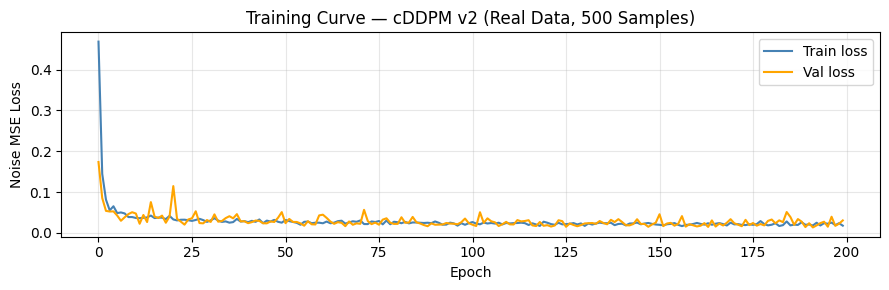

In [21]:
# ============================================================
# CELL 6 — Training
# ============================================================
EPOCHS    = 200
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
criterion = nn.MSELoss()

train_losses, val_losses = [], []
best_val_loss = float('inf')

print(f'Training: {EPOCHS} epochs | {N_TRAIN} train / {N_VAL} val samples\n')
model.train()

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    t_loss = 0.0
    for bn, cv in train_loader:
        bn, cv = bn.to(DEVICE), cv.to(DEVICE)
        t  = torch.randint(0, T, (cv.shape[0],), device=DEVICE).long()
        eps = torch.randn_like(cv)
        x_t = gather(sqrt_acp, t, cv.shape) * cv + \
              gather(sqrt_one_minus_acp, t, cv.shape) * eps
        loss = criterion(model(x_t, bn, t), eps)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_loss += loss.item()

    # --- Validate ---
    model.eval()
    v_loss = 0.0
    with torch.no_grad():
        for bn, cv in val_loader:
            bn, cv = bn.to(DEVICE), cv.to(DEVICE)
            t  = torch.randint(0, T, (cv.shape[0],), device=DEVICE).long()
            eps = torch.randn_like(cv)
            x_t = gather(sqrt_acp, t, cv.shape) * cv + \
                  gather(sqrt_one_minus_acp, t, cv.shape) * eps
            v_loss += criterion(model(x_t, bn, t), eps).item()

    avg_t = t_loss / len(train_loader)
    avg_v = v_loss / len(val_loader)
    train_losses.append(avg_t)
    val_losses.append(avg_v)
    scheduler.step()

    # Save best model
    if avg_v < best_val_loss:
        best_val_loss = avg_v
        torch.save(model.state_dict(), 'dm_v2_best.pt')

    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch+1:>3}/{EPOCHS} | train: {avg_t:.5f} | val: {avg_v:.5f} '
              f'| best_val: {best_val_loss:.5f}')

# Load best weights for evaluation
model.load_state_dict(torch.load('dm_v2_best.pt', map_location=DEVICE))
print(f'\nTraining done. Best val loss: {best_val_loss:.5f}')

# Plot
plt.figure(figsize=(9, 3))
plt.plot(train_losses, label='Train loss', color='steelblue')
plt.plot(val_losses,   label='Val loss',   color='orange')
plt.xlabel('Epoch')
plt.ylabel('Noise MSE Loss')
plt.title('Training Curve — cDDPM v2 (Real Data, 500 Samples)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_train_curve_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ============================================================
# CELL 7 — Refinement sampler
# ============================================================
@torch.no_grad()
def refine(model, noisy_cond, t_start=30):
    """
    Partial reverse diffusion starting at t_start.
    t_start=30 means we only denoise the last 15% of the schedule —
    appropriate for refinement (not full generation from pure noise).
    """
    model.eval()
    cond = noisy_cond.to(DEVICE)           # (1, 1, 1250)

    # Start: encode the noisy condition into the diffusion trajectory
    t_b = torch.full((1,), t_start, device=DEVICE, dtype=torch.long)
    img = gather(sqrt_acp, t_b, cond.shape) * cond + \
          gather(sqrt_one_minus_acp, t_b, cond.shape) * torch.randn_like(cond)

    for i in range(t_start, -1, -1):
        t = torch.full((1,), i, device=DEVICE, dtype=torch.long)

        beta_t    = gather(betas, t, img.shape)
        sqrt_1m   = gather(sqrt_one_minus_acp, t, img.shape)
        sqrt_a    = gather(sqrt_acp, t, img.shape)
        acp_t     = gather(alphas_cumprod, t, img.shape)
        acp_prev  = gather(alphas_cumprod_prev, t, img.shape)
        alpha_t   = gather(alphas, t, img.shape)

        # Predict noise → estimate x0
        eps_pred = model(img, cond, t)
        x0_pred  = (img - sqrt_1m * eps_pred) / (sqrt_a + 1e-8)
        x0_pred  = torch.clamp(x0_pred, -1.5, 1.5)  # wider clamp for real data

        # Posterior mean
        coef1 = beta_t * torch.sqrt(acp_prev) / (1.0 - acp_t + 1e-8)
        coef2 = (1.0 - acp_prev) * torch.sqrt(alpha_t) / (1.0 - acp_t + 1e-8)
        mean  = coef1 * x0_pred + coef2 * img

        img = mean if i == 0 else mean + 0.5 * torch.sqrt(beta_t) * torch.randn_like(img)

    return img


print('Sampler ready.')

Sampler ready.


---
# Part 3 — Pipeline Integration
Runs Baseline vs Baseline+DM on the same 20 validation images.
The DM is inserted **after** `convert_scanned_both` and **before** evaluation.

Running integration comparison: images 400-409, types [3, 11]
DM t_start=30  |  sig_len=1250



  0%|          | 0/10 [00:00<?, ?it/s]

  idx=400  type=3  Baseline=3.613  Baseline+DM=3.593  Δ=-0.020  ✗


 10%|█         | 1/10 [00:10<01:31, 10.15s/it]

  idx=400  type=11  Baseline=3.016  Baseline+DM=3.170  Δ=+0.154  ✓
  idx=401  type=3  Baseline=2.566  Baseline+DM=2.503  Δ=-0.062  ✗


...

  idx=407  type=11  Baseline=2.207  Baseline+DM=2.212  Δ=+0.005  ✓
  idx=408  type=3  Baseline=3.146  Baseline+DM=2.977  Δ=-0.169  ✗


 90%|█████████ | 9/10 [01:21<00:08,  8.98s/it]

  idx=408  type=11  Baseline=2.542  Baseline+DM=2.547  Δ=+0.006  ✓
  idx=409  type=3  Baseline=3.738  Baseline+DM=3.580  Δ=-0.158  ✗


100%|██████████| 10/10 [01:29<00:00,  8.99s/it]

  idx=409  type=11  Baseline=3.464  Baseline+DM=3.266  Δ=-0.198  ✗

INTEGRATION RESULTS — Baseline vs Baseline + DM
                                      Baseline    Base+DM
------------------------------------------------------------
Mean SNR (linear)                       3.2151     3.2369
Mean SNR (dB)                           5.0720     5.1013
Mean delta SNR                                    +0.0218
Images improved by DM                               12/20

Isolated DM result (from training notebook): +15.74% MSE improvement
Pipeline integration result:                 +0.68% SNR change


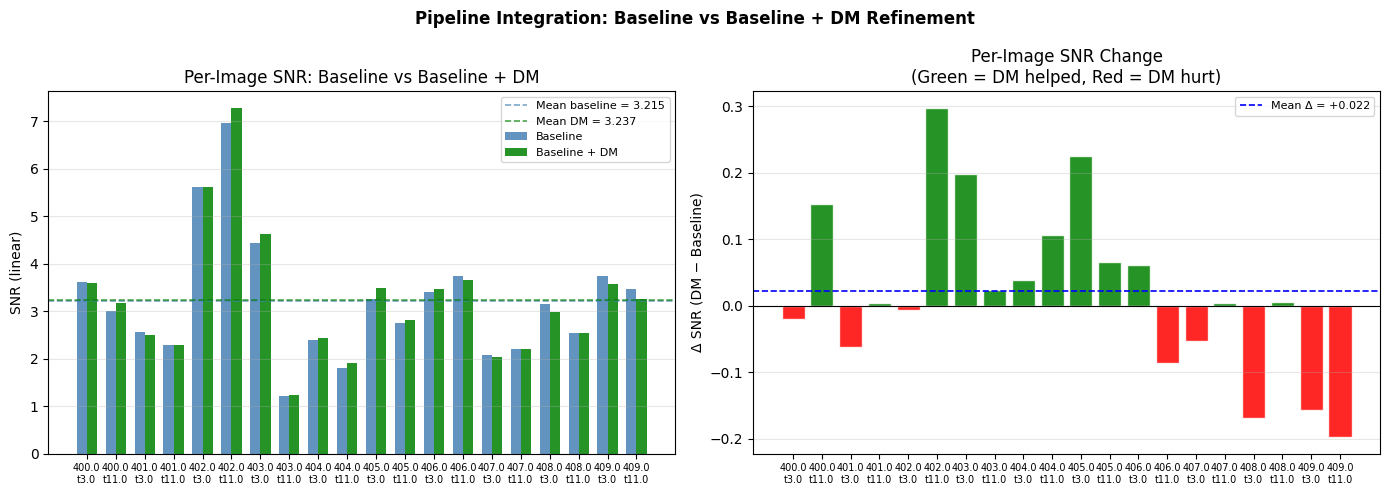

Saved: fig_integration.png  |  integration_results.csv


In [23]:
# ============================================================
# INTEGRATION — Baseline vs Baseline + DM
# Runs the SAME images used in the baseline validation above
# (train images 400-409, image types 3 and 11) and computes
# competition SNR for both pipelines side by side.
#
# Pipeline:
#   Baseline : ECG Image → convert_scanned_both → preds → SNR
#   Baseline+DM: ECG Image → convert_scanned_both → DM refine → preds_dm → SNR
# ============================================================
import scipy.signal as ss_resamp

DM_SIG_LEN = 1250   # length the DM was trained on
T_START    = 30     # partial diffusion steps (refinement, not generation)

# ── Helper: refine one lead signal (mV) with the DM ─────────────────────────
@torch.no_grad()
def dm_refine_mv(signal_mv):
    """
    Input : 1D numpy array in mV, any length
    Output: 1D numpy array in mV, same length, DM-refined

    Normalization: INDEPENDENT (no clean reference at inference).
    This is the honest real-world setting.
    """
    sig      = np.nan_to_num(np.array(signal_mv, dtype=np.float64))
    orig_len = len(sig)
    if orig_len < 10:
        return signal_mv

    # Resample to DM input length if needed
    sig_rs = ss_resamp.resample(sig, DM_SIG_LEN) if orig_len != DM_SIG_LEN else sig.copy()

    # Normalize to [-1, 1]
    s_min, s_max = sig_rs.min(), sig_rs.max()
    s_rng = s_max - s_min
    if s_rng < 1e-8:
        return signal_mv   # flat — nothing to refine

    sig_norm = (2.0 * (sig_rs - s_min) / s_rng - 1.0).astype(np.float32)
    cond     = torch.FloatTensor(sig_norm).unsqueeze(0).unsqueeze(0).to(DEVICE)

    # Partial reverse diffusion
    t_b = torch.full((1,), T_START, device=DEVICE, dtype=torch.long)
    img = gather(sqrt_acp, t_b, cond.shape) * cond + \
          gather(sqrt_one_minus_acp, t_b, cond.shape) * torch.randn_like(cond)

    for i in range(T_START, -1, -1):
        t_i      = torch.full((1,), i, device=DEVICE, dtype=torch.long)
        beta_t   = gather(betas,              t_i, img.shape)
        sqrt_1m  = gather(sqrt_one_minus_acp, t_i, img.shape)
        sqrt_a   = gather(sqrt_acp,           t_i, img.shape)
        acp_t    = gather(alphas_cumprod,     t_i, img.shape)
        acp_p    = gather(alphas_cumprod_prev,t_i, img.shape)
        alpha_t  = gather(alphas,             t_i, img.shape)

        eps_pred = model(img, cond, t_i)
        x0_pred  = torch.clamp((img - sqrt_1m * eps_pred) / (sqrt_a + 1e-8), -1.5, 1.5)
        mean     = (beta_t * torch.sqrt(acp_p) / (1.0 - acp_t + 1e-8)) * x0_pred + \
                   ((1.0 - acp_p) * torch.sqrt(alpha_t) / (1.0 - acp_t + 1e-8)) * img
        img      = mean if i == 0 else mean + 0.5 * torch.sqrt(beta_t) * torch.randn_like(img)

    refined_norm = img.cpu().numpy().flatten()
    refined_mv   = (refined_norm + 1.0) * s_rng / 2.0 + s_min  # denormalize

    # Resample back to original length
    if orig_len != DM_SIG_LEN:
        refined_mv = ss_resamp.resample(refined_mv, orig_len)

    return refined_mv.astype(np.float64)


# ── Comparison loop ──────────────────────────────────────────────────────────
VAL_START = 400
VAL_END   = 410
VAL_TYPES = [3, 11]

results = []
print(f"Running integration comparison: images {VAL_START}-{VAL_END-1}, types {VAL_TYPES}")
print(f"DM t_start={T_START}  |  sig_len={DM_SIG_LEN}\n")

for idx, ima, img_type, labels in train_images_and_labels(
        start=VAL_START, end=VAL_END,
        image_types=VAL_TYPES, use_tqdm=True):

    # Step 1: Digitize with the full ensemble baseline
    try:
        markers     = mf.find_markers(ima, plot=False)
        n_timesteps = {lead: (~labels[lead].isna()).sum() for lead in LEADS}
        preds       = convert_scanned_both(ima, markers, n_timesteps, verbose=False)
        row         = train[train['id'] == idx]
        fs          = int(row['fs'].values[0]) if len(row) > 0 else 500
    except Exception as e:
        print(f"  Skip idx={idx}: {e}")
        continue

    # Step 2: Apply DM to each lead → preds_dm
    preds_dm = {}
    for lead in LEADS:
        raw = preds.get(lead)
        if raw is None:
            preds_dm[lead] = None
            continue
        try:
            preds_dm[lead] = dm_refine_mv(raw)
        except Exception:
            preds_dm[lead] = raw   # fallback to baseline if DM fails

    # Step 3: Compute SNR for BOTH
    ss_base, sn_base = 0.0, 0.0
    ss_dm,   sn_dm   = 0.0, 0.0

    for lead in LEADS:
        label = labels[lead].dropna().values
        if len(label) < 10:
            continue

        # Baseline SNR
        pred_b = preds.get(lead)
        if pred_b is not None:
            try:
                ab = align_signals(label, pred_b, int(fs * MAX_TIME_SHIFT))
                ps, pn = compute_power(label, ab.copy())
                ss_base += ps;  sn_base += pn
            except Exception:
                pass

        # DM SNR
        pred_d = preds_dm.get(lead)
        if pred_d is not None:
            try:
                ad = align_signals(label, pred_d, int(fs * MAX_TIME_SHIFT))
                ps, pn = compute_power(label, ad.copy())
                ss_dm += ps;  sn_dm += pn
            except Exception:
                # fallback: use baseline numbers so DM doesn't get unfair penalty
                if pred_b is not None:
                    try:
                        ab = align_signals(label, pred_b, int(fs * MAX_TIME_SHIFT))
                        ps, pn = compute_power(label, ab.copy())
                        ss_dm += ps;  sn_dm += pn
                    except Exception:
                        pass

    snr_base = compute_snr(ss_base, sn_base)
    snr_dm   = compute_snr(ss_dm,   sn_dm)
    delta    = snr_dm - snr_base

    results.append({
        'idx':          idx,
        'img_type':     img_type,
        'snr_baseline': round(snr_base, 4),
        'snr_dm':       round(snr_dm,   4),
        'delta':        round(delta,    4),
    })
    mark = "✓" if delta > 0 else "✗"
    print(f"  idx={idx}  type={img_type}  "
          f"Baseline={snr_base:.3f}  Baseline+DM={snr_dm:.3f}  "
          f"Δ={delta:+.3f}  {mark}")


# ── Results table ─────────────────────────────────────────────────────────────
df = pd.DataFrame(results)
df.to_csv('integration_results.csv', index=False)

mean_base = df['snr_baseline'].mean()
mean_dm   = df['snr_dm'].mean()
mean_d    = df['delta'].mean()
n_imp     = (df['delta'] > 0).sum()
n_tot     = len(df)

print()
print('='*60)
print('INTEGRATION RESULTS — Baseline vs Baseline + DM')
print('='*60)
print(f'{"":35} {"Baseline":>10} {"Base+DM":>10}')
print('-'*60)
print(f'{"Mean SNR (linear)":35} {mean_base:>10.4f} {mean_dm:>10.4f}')
print(f'{"Mean SNR (dB)":35} {10*np.log10(max(mean_base,1e-9)):>10.4f} {10*np.log10(max(mean_dm,1e-9)):>10.4f}')
print(f'{"Mean delta SNR":35} {"":>10} {mean_d:>+10.4f}')
print(f'{"Images improved by DM":35} {"":>10} {f"{n_imp}/{n_tot}":>10}')
print('='*60)
print()
print(f'Isolated DM result (from training notebook): +15.74% MSE improvement')
print(f'Pipeline integration result:                 {mean_d/mean_base*100:+.2f}% SNR change')


# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x   = np.arange(len(df))
w   = 0.35
lbl = [f'{r["idx"]}\nt{r["img_type"]}' for _, r in df.iterrows()]

# Grouped bar: baseline vs DM per image
axes[0].bar(x - w/2, df['snr_baseline'], w,
            label='Baseline', color='steelblue', alpha=0.85)
axes[0].bar(x + w/2, df['snr_dm'], w,
            label='Baseline + DM', color='green', alpha=0.85)
axes[0].axhline(mean_base, color='steelblue', linestyle='--',
                linewidth=1.2, alpha=0.7, label=f'Mean baseline = {mean_base:.3f}')
axes[0].axhline(mean_dm,   color='green',     linestyle='--',
                linewidth=1.2, alpha=0.7, label=f'Mean DM = {mean_dm:.3f}')
axes[0].set_xticks(x);  axes[0].set_xticklabels(lbl, fontsize=7)
axes[0].set_ylabel('SNR (linear)')
axes[0].set_title('Per-Image SNR: Baseline vs Baseline + DM')
axes[0].legend(fontsize=8);  axes[0].grid(True, alpha=0.3, axis='y')

# Delta per image
bar_cols = ['green' if d > 0 else 'red' for d in df['delta']]
axes[1].bar(x, df['delta'], color=bar_cols, alpha=0.85, edgecolor='white')
axes[1].axhline(0,      color='black', linewidth=0.8)
axes[1].axhline(mean_d, color='blue',  linestyle='--',
                linewidth=1.2, label=f'Mean Δ = {mean_d:+.3f}')
axes[1].set_xticks(x);  axes[1].set_xticklabels(lbl, fontsize=7)
axes[1].set_ylabel('Δ SNR (DM − Baseline)')
axes[1].set_title('Per-Image SNR Change\n(Green = DM helped, Red = DM hurt)')
axes[1].legend(fontsize=8);  axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Pipeline Integration: Baseline vs Baseline + DM Refinement',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_integration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_integration.png  |  integration_results.csv')
